# VGG16 model architecture 

## import library

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization,GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint
from keras.utils import Sequence
from tensorflow.keras.callbacks import EarlyStopping
from keras.optimizers import Adam

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import requests
import csv


load the vgg16 model

In [2]:
# Load the VGG16 model without the top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Freeze the base model layers
#for layer in base_model.layers:
    #layer.trainable = False

# Add custom layers on top of the base model
#x = Flatten()(base_model.output)

#x = Dense(512, activation='relu',kernel_initializer = 'he_normal')(x)
#x = BatchNormalization()(x)
#x = Dropout(0.25)(x)

#x = Dense(2048, activation='relu',kernel_initializer = 'he_normal')(x)
#x = BatchNormalization()(x)
#x = Dropout(0.5)(x)

#output = Dense(3, activation='softmax')(x)  # Adjust the number of classes as needed

In [4]:
# Add custom layers for classification with dropout
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation="relu",kernel_initializer = 'he_normal')(x)  # Reduced dense layer size
x = BatchNormalization()(x)

x = Dropout(0.5)(x)  # Increased dropout rate

output = Dense(3, activation="softmax")(x)



In [5]:
# Create the complete model
model = Model(inputs=base_model.input, outputs=output)

# Summary of the model
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,07

 Total params: 15,247,171 (58.16 MB)

 Trainable params: 15,245,123 (58.16 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [6]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss="CategoricalCrossentropy", metrics=['accuracy'])


## Set training and validation data

In [7]:
# Create an ImageDataGenerator for data augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,  # Rescale pixel values to [0, 1]
    rotation_range=30,  # Increased rotation range
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,  # Added shear range
    zoom_range=0.2,  # Added zoom range
    horizontal_flip=True,
    validation_split=0.2
)



In [8]:
train_generator = train_datagen.flow_from_directory(
    "/kaggle/input/cucumber-leaf-disease-dataset/cucumber_Leaf_Disease/train",
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='training')  # Set as training data

validation_generator = train_datagen.flow_from_directory(
    "/kaggle/input/cucumber-leaf-disease-dataset/cucumber_Leaf_Disease/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation')  # Set as validation data

Found 2964 images belonging to 3 classes.
Found 739 images belonging to 3 classes.


## Mapping of class names to their corresponding numerical labels

In [9]:
# Get the mapping of class names to their corresponding numerical labels
class_indices = train_generator.class_indices

# Reverse the dictionary to get the mapping of labels to class names
classes = {v: k for k, v in class_indices.items()}

# Now, 'classes' contains the mapping from numerical labels to class names
print(classes)

{0: 'Downy_mildew', 1: 'Healthy_leaves', 2: 'Powdery_mildew'}


## Define model checkpoints to save best model

In [10]:
# Define the directory and filename for saving the best model
model_filename = 'CLD_VGG16.keras'

# Combine the directory and filename
model_path = model_filename

# Define the ModelCheckpoint callback
checkpoint = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)

In [11]:
best_weights = ModelCheckpoint('CLD_VGG16.weights.h5',
                               monitor='val_loss',
                               verbose=0,
                               save_weights_only=True,
                               save_best_only=True,
                               mode='min',
                               save_freq='epoch')


last_weights = ModelCheckpoint('CLD_VGG16.weights.h5',
                               monitor='val_loss',
                               verbose=0,
                               save_weights_only=True,
                               save_best_only=False,
                               mode='auto',
                               save_freq='epoch')

# Define EarlyStopping and ModelCheckpoint callbacks
early_stopping = EarlyStopping(monitor='val_loss',
                                       patience=10,
                                       restore_best_weights=True,
                                       verbose=1)

## Training VGG16 model

In [12]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks = [checkpoint,best_weights,last_weights,early_stopping],
    verbose=1
)

Epoch 1/50


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1728578823.298828      63 service.cc:145] XLA service 0x7b0374005e30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1728578823.298886      63 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1728578861.466556      63 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8086 - loss: 0.4807
Epoch 1: val_loss improved from inf to 0.62661, saving model to CLD_VGG16.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.8105 - loss: 0.4761 - val_accuracy: 0.6874 - val_loss: 0.6266
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 965ms/step - accuracy: 0.9711 - loss: 0.0834
Epoch 2: val_loss improved from 0.62661 to 0.42946, saving model to CLD_VGG16.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.9712 - loss: 0.0831 - val_accuracy: 0.8119 - val_loss: 0.4295
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 992ms/step - accuracy: 0.9800 - loss: 0.0606
Epoch 3: val_loss did not improve from 0.42946
47/47 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9799 - loss: 0.0607 - val_accuracy: 0.7415 - val_loss: 0.7151
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 978ms/step - accuracy: 0.9834 - loss: 0.0533
Epoch 4: val_loss did not improve from 0.42946
47/47 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9834 - loss: 

## VGG16 Training statics

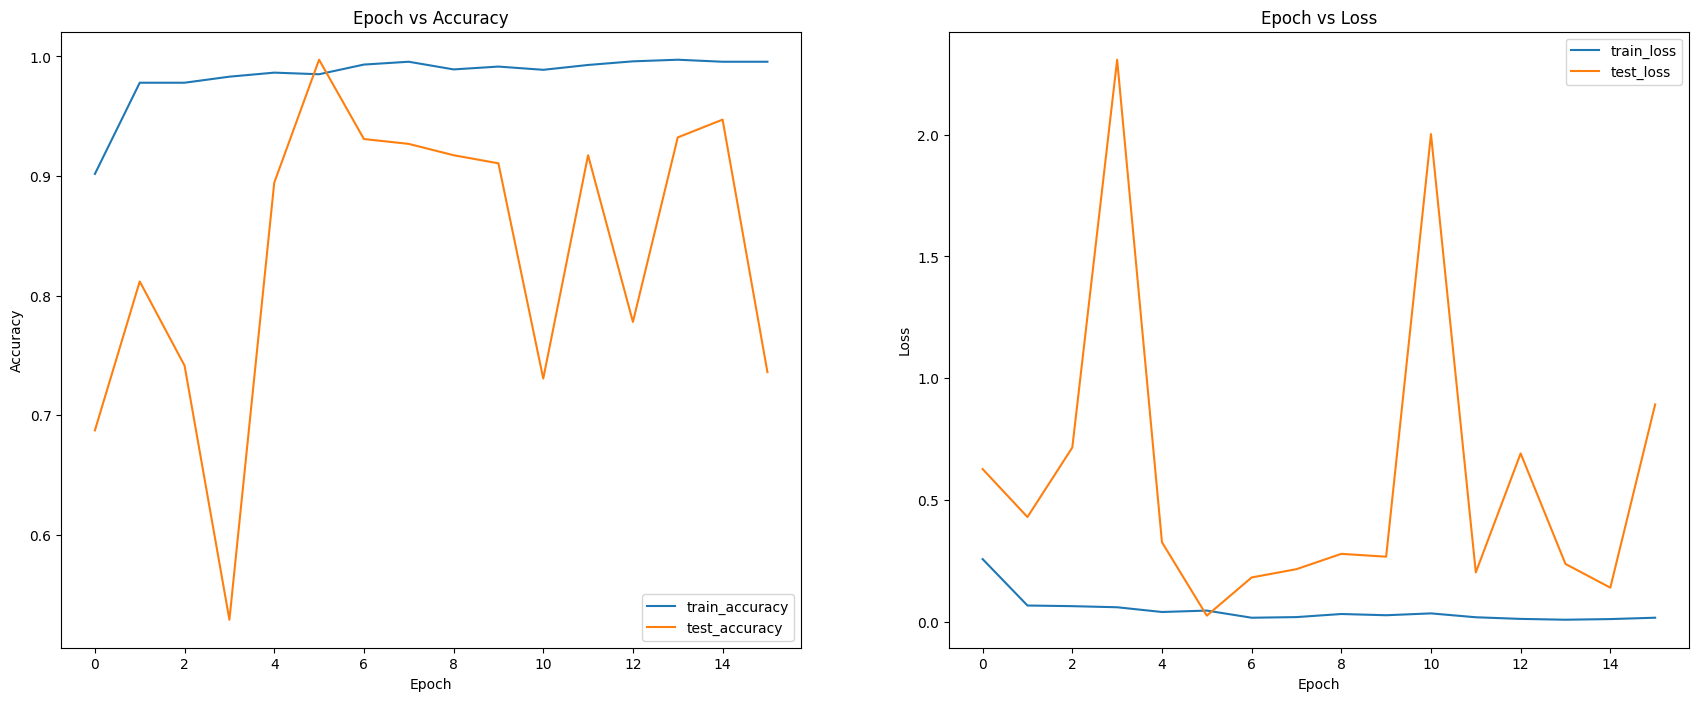

In [13]:
plt.figure(figsize=(21, 8))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='test_accuracy')
plt.title("Epoch vs Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')


plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='train_loss')
plt.plot(history.history["val_loss"], label='test_loss')
plt.title("Epoch vs Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

## Model evaluation

In [14]:
test_paths = []
path_to_subset = '/kaggle/input/cucumber-leaf-disease-dataset/cucumber_Leaf_Disease/test'
for folder in os.listdir(path_to_subset):

    for image in os.listdir(os.path.join(path_to_subset, folder)):
        path_to_image = os.path.join(path_to_subset, folder, image)

        #check image none or not none
        img = cv2.imread(path_to_image)
        if img is not None:
          test_paths.append( path_to_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━

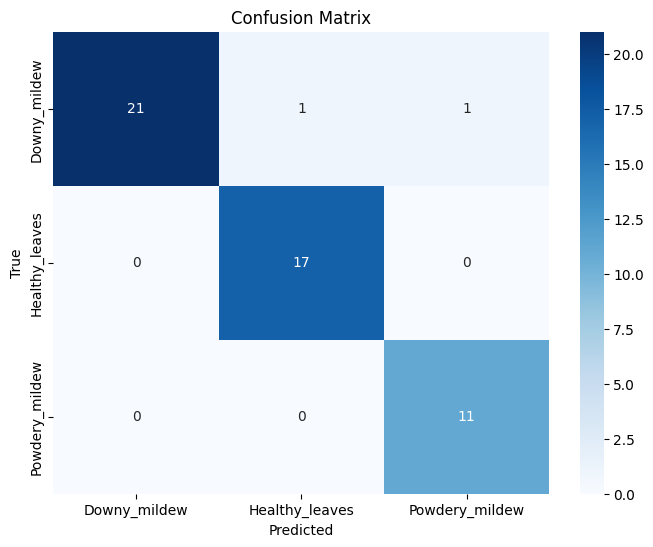

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [15]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


input_shape=(224,224,3)

def evaluation(model,test_paths):
    Real_labels=[]
    prdict_label=[]

    for i, image_path in enumerate(test_paths):
        image=cv2.imread(image_path)
        # Reading image, convert it to np array and decode
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        # Resize, scale and reshape image before making predictions
        resized = cv2.resize(image, (input_shape[0],input_shape[1]))
        resized = (resized / 255.0).reshape(-1, input_shape[1], input_shape[0], input_shape[2])


        classes={'Downy_mildew':0 ,'Healthy_leaves':1, 'Powdery_mildew':2}

        label = image_path.split(os.path.sep)[-2].split(' ')
        Real_labels.append(classes[f"{label[0]}"])


        # Predict results
        preds = model.predict(resized)
        indices = np.argmax(preds, axis=1)
        prdict_label.append(indices[0])
        
    # Generate classification report
    report = classification_report(Real_labels,prdict_label, target_names=['Downy_mildew','Healthy_leaves','Powdery_mildew'])
    print(report)

    # Compute confusion matrix
    cm = confusion_matrix(Real_labels,prdict_label)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Downy_mildew','Healthy_leaves','Powdery_mildew'], yticklabels=['Downy_mildew','Healthy_leaves','Powdery_mildew'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


        
        
    return Real_labels , prdict_label


Real_labels,prdict_label=evaluation(model,test_paths)
print(Real_labels)
print(prdict_label)

## Model inference

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Powdery_mildew
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Powdery_mildew
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Downy_mildew
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Healthy_leaves
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Healthy_leaves
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Powdery_mildew


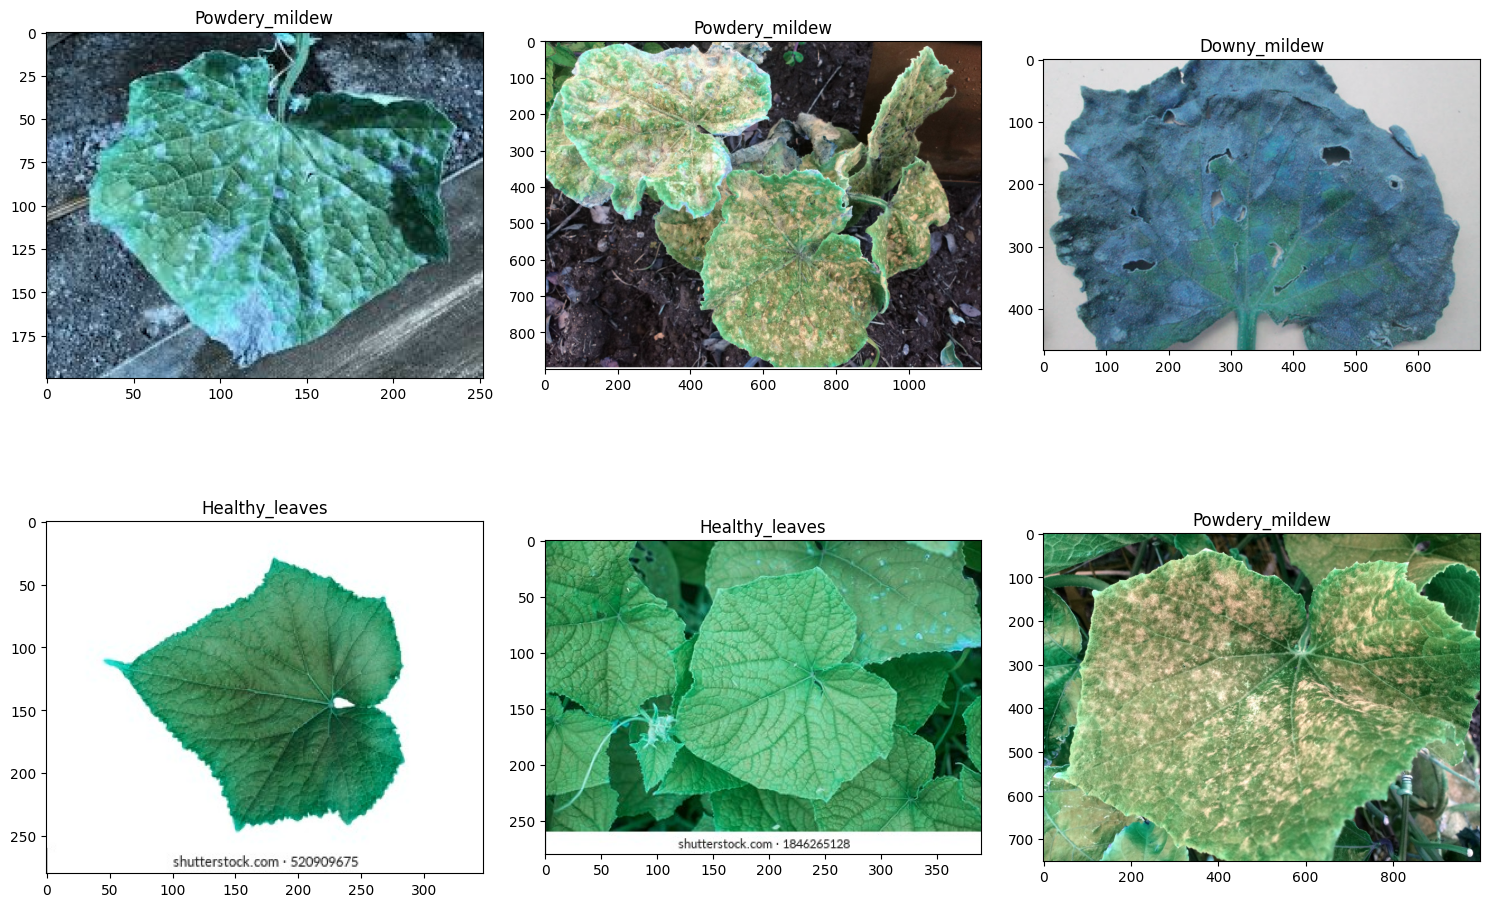

In [16]:


# URLs to images
urls = [
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRKWUtKGe5jbDyat4Xk523pQkqS1HWPAXHrLg&s","https://images.saymedia-content.com/.image/t_share/MTc0MzU0NDg3NTYwMDU0MTIw/plant-diseases-that-affect-cucumbers-and-how-to-treat-them.jpg",
    "https://ipm.missouri.edu/MEG/2019/8/cucumberDownyMildew/necroticLesion.jpg",
    "https://www.shutterstock.com/image-photo/leaf-cucumber-closeup-isolated-on-260nw-520909675.jpg",
    "https://www.shutterstock.com/image-photo/close-cucumber-leaves-garden-260nw-1846265128.jpg",
    "https://plantvillage-production-new.s3.amazonaws.com/image/100322/file/default-9e39cd1faa62d5ce010e00c80006977b.jpg"
    
    
    
]

fig = plt.figure(figsize = (15, 15))

for i, url in enumerate(urls):
    plt.subplot(331 + i)

    # Sending request to the URL
    r = requests.get(url, stream = True).raw

    # Reading image, convert it to np array and decode
    image = np.asarray(bytearray(r.read()), dtype="uint8")
    image = cv2.imdecode(image, cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    #image = img_to_array(image)


    # Resize, scale and reshape image before making predictions
    resized = cv2.resize(image, (input_shape[0],input_shape[1]))
    resized = (resized / 255.0).reshape(-1, input_shape[1], input_shape[0], input_shape[2])

    classes={0:'Downy_mildew',1:'Healthy_leaves',2:'Powdery_mildew'}
    
    # Predict results
    preds = model.predict(resized)
    indices = np.argmax(preds, axis=1)
    prdict_label=(classes[indices[0]])
    print(prdict_label)


    # Showing image
    plt.imshow(image[:, :, ::-1])
    plt.title(f'{prdict_label}')

plt.tight_layout()